# Topic: Overfitting Detection

## Definition (30-second explanation)
* Overfitting occurs when a machine learning model memorizes the training data—including its noise and random fluctuations—but fails to generalize to new, unseen data.
* It is mathematically characterized by high variance and visually diagnosed by a large gap between training and validation accuracy.

## Why Interviewers Ask This
* To verify your practical debugging skills; building a model is easy, but making it generalize is the core job of a Data Scientist.
* To test your fundamental understanding of the Bias-Variance Tradeoff.
* To see if you understand proper data splitting techniques (preventing test set contamination).

## Core Concepts
* **The Train-Test Gap:** The primary quantitative indicator. High train accuracy (e.g., 99%) + low test accuracy (e.g., 65%) = Overfitting.
* **Bias-Variance Tradeoff:** High Variance equates to overfitting (model is too sensitive to training data fluctuations). High Bias equates to underfitting (model is too simple).
* **Learning Curves:** Plotting training and validation scores against the number of training samples. An overfitting signature shows the two curves diverging as model complexity increases or training progresses.

## When to Use (Detection & Prevention)
* **Detection:** Use Learning Curves, K-Fold Cross Validation (look for high standard deviation in fold scores), and continuously monitor the train-val gap.
* **Prevention:** Reduce model complexity (e.g., shallower trees), apply Regularization (L1/L2, Dropout), use Early Stopping, gather more data, or use ensemble methods.

## Advantages (of proactive detection)
* Prevents deploying brittle, fragile models that fail in production.
* Saves massive amounts of compute time (via Early Stopping) by halting training once validation loss stops improving.

## Limitations
* Tuning hyperparameters extensively to close the train-val gap can lead to "Validation Set Overfitting," where the model implicitly memorizes the validation set.

## Common Comparisons
* **Overfitting vs. Underfitting:** Overfitting = complex model, high variance, divergent learning curves. Underfitting = simple model, high bias, both learning curves plateau at low accuracy.

## Common Interview Traps
* **Test Set Contamination (Data Leakage):** Tuning hyperparameters using the test set. ALWAYS use a 3-way split (Train / Validation / Test) or Cross-Validation. The test set should only be touched once at the very end.
* **Reporting only Training Accuracy:** A massive red flag in interviews that shows a lack of fundamental ML understanding.

## Python / SQL Syntax
```python
from sklearn.model_selection import learning_curve
import numpy as np

# Generates data for plotting learning curves
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model, 
    X=X, 
    y=y, 
    cv=5, 
    scoring='accuracy'
)
```

## Important Formula
* **Total Error:** $Total Error = Bias^2 + Variance + Irreducible Noise$

## 45-Second Interview Answer
"Overfitting is when a model learns the training data perfectly, including the noise, but fails to generalize to unseen data. I diagnose it primarily by looking for a large gap between training and validation performance, or by plotting learning curves to see if the validation curve diverges from the training curve. To fix it, I generally follow a hierarchy: first, I try to get more data or use data augmentation. If that's not possible, I reduce model complexity, apply regularization techniques like L1/L2 or Dropout, and implement Early Stopping to halt training before the model starts memorizing the data."

## Example Questions:

### Q1. What is the bias-variance tradeoff and how does it relate to overfitting?
* **Ideal Interview Answer:** The tradeoff states that total model error is composed of bias, variance, and irreducible noise. Bias is the error from a model being too simple (underfitting), while variance is the error from a model being excessively sensitive to small fluctuations in the training data. Overfitting is a state of high variance and low bias. As you increase model complexity to reduce bias, variance naturally increases, and finding the sweet spot between them is the key to generalization.
* **Common Mistakes:** Confusing the definitions of bias and variance (e.g., saying overfitting is high bias).
* **Likely Follow-up:** "If your model has high variance, what are two mathematical ways to reduce it?"

### Q2. How does regularization prevent overfitting in linear models?
* **Ideal Interview Answer:** Regularization adds a penalty term to the model's loss function based on the size of the feature coefficients. L2 regularization (Ridge) penalizes large squared coefficients, forcing the model to distribute weight evenly across features rather than relying too heavily on any single one. L1 regularization (Lasso) penalizes the absolute value of coefficients, which can drive less important feature weights to exactly zero, acting as built-in feature selection and reducing overall complexity.
* **Common Mistakes:** Forgetting that regularization changes the *loss function*, not the data itself.
* **Likely Follow-up:** "How do you decide between using L1 versus L2 regularization?"

### Q3. What does a learning curve look like for an overfitted model?
* **Ideal Interview Answer:** On a learning curve (plotting accuracy/loss against training epochs or sample size), an overfitted model will show the training accuracy starting high and staying very high, while the validation accuracy plateaus at a much lower level. Visually, as training progresses or complexity increases, the two curves diverge significantly, creating a wide gap.
* **Common Mistakes:** Confusing learning curves with ROC curves, or forgetting to specify which axis represents what.
* **Likely Follow-up:** "What does a learning curve look like for an underfitted model?"

### Q4. What is the difference between validation set and test set in hyperparameter tuning?
* **Ideal Interview Answer:** The validation set is actively used during the training phase to tune hyperparameters, apply early stopping, and compare different model architectures. Because we make decisions based on validation performance, the model implicitly "learns" from it. The test set is a completely hold-out dataset used strictly for final evaluation to estimate production performance. You must never tune hyperparameters on the test set to avoid test set contamination.
* **Common Mistakes:** Using the terms interchangeably or suggesting a simple 2-way (Train/Test) split is sufficient for complex hyperparameter tuning.
* **Likely Follow-up:** "If you only have a very small dataset of 500 rows, how do you handle this 3-way split constraint?"

### Q5. Why does a very deep decision tree tend to overfit?
* **Ideal Interview Answer:** A decision tree works by continuously partitioning the data. If left unconstrained (a very deep tree), it will keep splitting until every leaf node contains exactly one training sample. It essentially builds a massive if-else statement that memorizes every single noise point and outlier in the training data, leading to perfect training accuracy but terrible generalization. 
* **Common Mistakes:** Giving a generic "it's too complex" answer without explaining the mechanical splitting behavior of the tree.
* **Likely Follow-up:** "Besides `max_depth`, what other hyperparameters can you tune in a Decision Tree to prevent this?"

## Practice Questions:

### Q1:
**You are training a RandomForestClassifier for a classification task. You want to programmatically find the exact max_depth where the model transitions from a "Good Fit" to "Overfitting".**

**We define "Overfitting" for this specific problem as: The training accuracy is > 95% AND the gap between train and test accuracy becomes greater than 5% (0.05).**

**Question:**
Write a Python script that iterates through tree depths from 1 to 20. Inside the loop, train a RandomForestClassifier (using random_state=42). Calculate the train and test accuracies. The loop should print the exact max_depth where the model first meets our defined overfitting criteria, and then immediately break (stop training further).

In [5]:
# Data:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Mock Dataset
data = {
    'feature_1': [1.2, 3.4, 2.1, 5.5, 3.2, 1.1, 4.4, 2.9],
    'feature_2': [0.1, 0.9, 0.3, 0.8, 0.4, 0.2, 0.7, 0.5],
    'target': [0, 1, 0, 1, 0, 0, 1, 1]
}
df = pd.DataFrame(data)
X = df[['feature_1', 'feature_2']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
depths = range(1, 21)

for depth in depths:
    model = RandomForestClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f'Depth: {depth}')
    print(f'Training Accuracy: {train_acc}')
    print(f'Test Accuracy: {test_acc}\n')

    if train_acc > 0.95 and (train_acc - test_acc) > 0.05:
        print(f'Overfitting Criteria reached at Depth: {depth}')
        break

Depth: 1
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 2
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 3
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 4
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 5
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 6
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 7
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 8
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 9
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 10
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 11
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 12
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 13
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 14
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 15
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 16
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 17
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 18
Training Accuracy: 1.0
Test Accuracy: 1.0

Depth: 19
Training Accuracy: 1.0
Test Accuracy: 1.0

De

* **Interview Tip:** Always remember to use the absolute difference or explicitly subtract `test` from `train` since training accuracy in an overfitted model will strictly be higher than test accuracy. Using a `break` statement shows you understand computational efficiency—there is no need to keep training deeper trees once the threshold is crossed.

### Q2:Scenario: The "Small Gap" Trap vs Absolute Performance
**Context:** Model A (no regularization) has 99% Train / 82% Test (17% gap). Model B (heavy regularization) has 79% Train / 77% Test (2% gap). A junior DS wants to deploy Model B because it fits the textbook definition of a "Good Fit" with a small gap. Do you agree?

* **Answer:** 
I completely disagree with the junior Data Scientist. We should deploy Model A (or tune it further). The ultimate goal of machine learning is maximum generalization to unseen data. Model A successfully predicts unseen data 82% of the time, while Model B only hits 77%. The junior DS is falling into the trap of optimizing for a small train-test gap instead of absolute test performance. Model B has been regularized so heavily that it is now underfitting. The large gap in Model A is simply a diagnostic signal telling us we can likely improve that 82% even further by applying *light* regularization, but throwing away 5% of absolute test accuracy just to make the gap smaller is a critical mistake.
* **Common Mistakes:** Agreeing with the junior DS because a 17% gap looks "scary" or "messy" compared to a clean 2% gap.
* **Interview Tip:** In business and production ML, absolute metrics on hold-out data (Test Accuracy, F1, AUC) are king. Diagnostic metrics (like train-test gaps) are just compasses to guide your hyperparameter tuning.

### Q3:
**Scenario:**
You are evaluating a DecisionTreeClassifier and want to visually diagnose if it is overfitting or underfitting as it receives more data. You decide to plot a Learning Curve using 5-fold cross-validation.

**Question:**
Using scikit-learn's learning_curve function and matplotlib, write the Python code to generate and plot the training and validation accuracy curves.

In [20]:
# Data:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve

# Mock Dataset (1000 rows, 4 features)
np.random.seed(42)
X = pd.DataFrame(np.random.randn(1000, 4), columns=['f1', 'f2', 'f3', 'f4'])
y = pd.Series(np.random.randint(0, 2, 1000))

model = DecisionTreeClassifier(random_state=42)

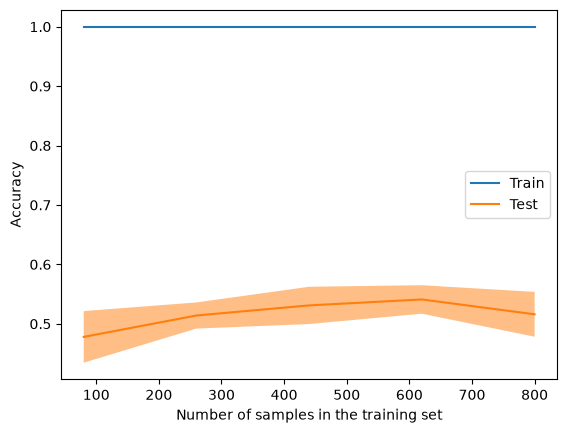

In [21]:
from sklearn.model_selection import learning_curve, LearningCurveDisplay
import matplotlib.pyplot as plt

# The modern, clean approach (scikit-learn >= 1.2)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model, 
    X=X, 
    y=y, 
    cv=5,
    scoring='accuracy'
)

display = LearningCurveDisplay(
    train_sizes=train_sizes,
    train_scores=train_scores,
    test_scores=test_scores,
    score_name="Accuracy"
)
display.plot()
plt.show()

* **Interview Tip:** While you can manually calculate `np.mean(axis=1)` for the scores and use `plt.plot()`, utilizing `LearningCurveDisplay` demonstrates that you stay up-to-date with modern library releases, which hiring managers love to see.